In [114]:
import ciropt as co
import cvxpy as cp
import numpy as np

import PEPit
import PEPit.functions as pep_func
from PEPit.constraint import Constraint as pep_constr
from PEPit.primitive_steps import proximal_step as pep_proximal_step

import ciropt.function as co_func
from ciropt.constraint import Constraint as co_constr
from ciropt.circuit_opt import CircuitOpt
from ciropt.utils import define_function
import ciropt as co


def dadmm_star(mus, L_smooth, R, C, L, params=None):
    # graph with 5 nodes and 4 edges (1,2), (1,3), (1,4), (1,5)
    #       5
    #       |
    #  2 -- 1 -- 4 
    #       |  
    #       5      

    if params is not None:
        problem = PEPit.PEP()
        package = pep_func
        Constraint = pep_constr
        proximal_step = pep_proximal_step
        h, eta, rho, gamma = params["h"], params["eta"], params["rho"], params["gamma"]
        
    else:
        problem = CircuitOpt()
        package = co_func
        Constraint = co_constr
        proximal_step = co_func.proximal_step
        h, eta, rho, gamma = problem.h, problem.eta, problem.rho, problem.gamma


    # -- define each f_j
    fs = []  # list of functions
    fs.append(define_function(problem, mus[1], L_smooth, package))
    for i in range(1,5):
        f = define_function(problem, mus[0], L_smooth, package)
        fs.append(f)
        
    # -- get global optimum
    x_star, y_star, f_star = (fs[0]+fs[1]+fs[2]+fs[3]+fs[4]).stationary_point(return_gradient_and_function_value=True)
    # -- set up initial states and equilibrium currents per edge...
    y1_star, f1_star = fs[0].oracle(x_star)
    y2_star, f2_star = fs[1].oracle(x_star)
    y3_star, f3_star = fs[2].oracle(x_star)
    y4_star, f4_star = fs[3].oracle(x_star)
    y5_star, f5_star = fs[4].oracle(x_star)

    # -- define the constraints
    problem.add_constraint(Constraint((y1_star + y2_star + y3_star + y4_star + y5_star - y_star) ** 2, "equality"))

    y1_12_star = problem.set_initial_point()
    y1_13_star = problem.set_initial_point()
    y1_14_star = problem.set_initial_point()
    y1_15_star = problem.set_initial_point()

    problem.add_constraint(Constraint((y1_12_star + y1_13_star + y1_14_star + y1_15_star - y1_star) ** 2, "equality"))

    e_12_1 = problem.set_initial_point()
    e_13_1 = problem.set_initial_point()
    e_14_1 = problem.set_initial_point()
    e_15_1 = problem.set_initial_point()

    i_L_12_1 = problem.set_initial_point()
    i_L_13_1 = problem.set_initial_point()
    i_L_14_1 = problem.set_initial_point()
    i_L_15_1 = problem.set_initial_point()

    x1_2, y1_2, f1_2 = proximal_step((1/5)*((R * i_L_12_1 + e_12_1) + (R * i_L_13_1 + e_13_1) +\
                                    (R * i_L_14_1 + e_14_1) + (R * i_L_15_1 + e_15_1)),\
                                    fs[0], R/5)
    x2_2, y2_2, f2_2 = proximal_step(R * i_L_12_1 + e_12_1, fs[1], R)
    x3_2, y3_2, f3_2 = proximal_step(R * i_L_13_1 + e_13_1, fs[2], R)
    x4_2, y4_2, f4_2 = proximal_step(R * i_L_14_1 + e_14_1, fs[3], R)
    x5_2, y5_2, f5_2 = proximal_step(R * i_L_15_1 + e_15_1, fs[4], R)

    e_12_2 = (x1_2 + x2_2)/2
    e_13_2 = (x1_2 + x3_2)/2
    e_14_2 = (x1_2 + x4_2)/2
    e_15_2 = (x1_2 + x5_2)/2

    i_L_12_2 = i_L_12_1 + (h / L) * (e_12_1 - x1_2)
    i_L_13_2 = i_L_13_1 + (h / L) * (e_13_1 - x1_2)
    i_L_14_2 = i_L_14_1 + (h / L) * (e_14_1 - x1_2)
    i_L_15_2 = i_L_15_1 + (h / L) * (e_15_1 - x1_2)

    E_1 = gamma * ((e_12_1 - x_star) ** 2 + (e_13_1 - x_star) ** 2 + (e_14_1 - x_star) ** 2 + (e_15_1 - x_star) ** 2)\
        + L * ((i_L_12_1 - y1_12_star) ** 2 + (i_L_13_1 - y1_13_star) ** 2 +\
                (i_L_14_1 - y1_14_star) ** 2 + (i_L_15_1 - y1_15_star) ** 2)\


    E_2 = gamma * ((e_12_2 - x_star) ** 2 + (e_13_2 - x_star) ** 2 + (e_14_2 - x_star) ** 2 + (e_15_2 - x_star) ** 2)\
        + L * ((i_L_12_2 - y1_12_star) ** 2 + (i_L_13_2 - y1_13_star) ** 2 +\
                (i_L_14_2 - y1_14_star) ** 2 + (i_L_15_2 - y1_15_star) ** 2)\
                
    Delta_2 = rho * (2/R) * ((e_12_2 - x1_2)**2 + (e_13_2 - x1_2)**2 + (e_14_2 - x1_2)**2 + (e_15_2 - x1_2)**2)\
        + eta * ( f1_2 - f1_star - y1_star * (x1_2 - x_star) \
                    + f2_2 - f2_star - y2_star * (x2_2 - x_star) \
                    + f3_2 - f3_star - y3_star * (x3_2 - x_star) \
                    + f4_2 - f4_star - y4_star * (x4_2 - x_star) \
                    + f5_2 - f5_star - y5_star * (x5_2 - x_star)) \
    
    problem.set_performance_metric(E_2 - (E_1 - Delta_2))

    return problem

def dadmm_star_accelerated(mus, L_smooth, R, C, L, params=None):
    # graph with 5 nodes and 4 edges (1,2), (1,3), (1,4), (1,5)
    #       5
    #       |
    #  2 -- 1 -- 4 
    #       |  
    #       5      

    if params is not None:
        problem = PEPit.PEP()
        package = pep_func
        Constraint = pep_constr
        proximal_step = pep_proximal_step
        h, eta, rho, gamma = params["h"], params["eta"], params["rho"], params["gamma"]
        
    else:
        problem = CircuitOpt()
        package = co_func
        Constraint = co_constr
        proximal_step = co_func.proximal_step
        h, eta, rho, gamma = problem.h, problem.eta, problem.rho, problem.gamma


    # -- define each f_j
    fs = []  # list of functions
    fs.append(define_function(problem, mus[1], L_smooth, package))
    for i in range(1,5):
        f = define_function(problem, mus[0], L_smooth, package)
        fs.append(f)
        
    # -- get global optimum
    x_star, y_star, f_star = (fs[0]+fs[1]+fs[2]+fs[3]+fs[4]).stationary_point(return_gradient_and_function_value=True)
    # -- set up initial states and equilibrium currents per edge...
    y1_star, f1_star = fs[0].oracle(x_star)
    y2_star, f2_star = fs[1].oracle(x_star)
    y3_star, f3_star = fs[2].oracle(x_star)
    y4_star, f4_star = fs[3].oracle(x_star)
    y5_star, f5_star = fs[4].oracle(x_star)

    # -- define the constraints
    problem.add_constraint(Constraint((y1_star + y2_star + y3_star + y4_star + y5_star - y_star) ** 2, "equality"))

    y1_12_star = problem.set_initial_point()
    y1_13_star = problem.set_initial_point()
    y1_14_star = problem.set_initial_point()
    y1_15_star = problem.set_initial_point()

    problem.add_constraint(Constraint((y1_12_star + y1_13_star + y1_14_star + y1_15_star - y1_star) ** 2, "equality"))

    e_12_1 = problem.set_initial_point()
    e_13_1 = problem.set_initial_point()
    e_14_1 = problem.set_initial_point()
    e_15_1 = problem.set_initial_point()

    i_L_12_1 = problem.set_initial_point()
    i_L_13_1 = problem.set_initial_point()
    i_L_14_1 = problem.set_initial_point()
    i_L_15_1 = problem.set_initial_point()

    e_C_1 = problem.set_initial_point()   # the “capacitor voltage” at node 1
    i_C_1 = problem.set_initial_point()   # its conjugate “current” 

    x1_2, y1_2, f1_2 = proximal_step((1/5)*((R * i_L_12_1 + e_12_1) + (R * i_L_13_1 + e_13_1) +\
                                    (R * i_L_14_1 + e_14_1) + (R * i_L_15_1 + e_15_1)),\
                                    fs[0], R/5)
    x2_2, y2_2, f2_2 = proximal_step(R * i_L_12_1 + e_12_1, fs[1], R)
    x3_2, y3_2, f3_2 = proximal_step(R * i_L_13_1 + e_13_1, fs[2], R)
    x4_2, y4_2, f4_2 = proximal_step(R * i_L_14_1 + e_14_1, fs[3], R)
    x5_2, y5_2, f5_2 = proximal_step(R * i_L_15_1 + e_15_1, fs[4], R)

    e_12_2 = (x1_2 + x2_2)/2
    e_13_2 = (x1_2 + x3_2)/2
    e_14_2 = (x1_2 + x4_2)/2
    e_15_2 = (x1_2 + x5_2)/2
    e_C_2 = e_C_1 - (h / C) * (
    i_C_1
    + i_L_12_1
    + i_L_13_1
    + i_L_14_1
    + i_L_15_1
    + (e_C_1 - x1_2) / R
)

    i_L_12_2 = i_L_12_1 + (h / L) * (e_12_1 - x1_2)
    i_L_13_2 = i_L_13_1 + (h / L) * (e_13_1 - x1_2)
    i_L_14_2 = i_L_14_1 + (h / L) * (e_14_1 - x1_2)
    i_L_15_2 = i_L_15_1 + (h / L) * (e_15_1 - x1_2)
    i_C_2 = i_C_1 + (h/L)*(e_C_1 - x1_2)


    E_1 = gamma * ((e_12_1 - x_star) ** 2 + (e_13_1 - x_star) ** 2 + (e_14_1 - x_star) ** 2 + (e_15_1 - x_star) ** 2)\
        + L * ((i_L_12_1 - y1_12_star) ** 2 + (i_L_13_1 - y1_13_star) ** 2 +\
                (i_L_14_1 - y1_14_star) ** 2 + (i_L_15_1 - y1_15_star) ** 2)\
                + (C/2) * (e_C_1 - x_star)**2


    E_2 = gamma * ((e_12_2 - x_star) ** 2 + (e_13_2 - x_star) ** 2 + (e_14_2 - x_star) ** 2 + (e_15_2 - x_star) ** 2)\
        + L * ((i_L_12_2 - y1_12_star) ** 2 + (i_L_13_2 - y1_13_star) ** 2 +\
                (i_L_14_2 - y1_14_star) ** 2 + (i_L_15_2 - y1_15_star) ** 2)\
                + (C/2) * (e_C_2 - x_star)**2
                
    Delta_2 = rho * (2/R) * ((e_12_2 - x1_2)**2 + (e_13_2 - x1_2)**2 + (e_14_2 - x1_2)**2 + (e_15_2 - x1_2)**2)\
        + eta * ( f1_2 - f1_star - y1_star * (x1_2 - x_star) \
                    + f2_2 - f2_star - y2_star * (x2_2 - x_star) \
                    + f3_2 - f3_star - y3_star * (x3_2 - x_star) \
                    + f4_2 - f4_star - y4_star * (x4_2 - x_star) \
                    + f5_2 - f5_star - y5_star * (x5_2 - x_star)) \
    
    Delta_2 += rho * (1/R) * ((e_C_2 - x1_2)**2 + e_C_2**2)
    
    problem.set_performance_metric(E_2 - (E_1 - Delta_2))

    return problem



In [145]:
A = 1.0
mus   = [0, A]
L_smooth = float("inf")
L     = 10.0
R     = 15.0
C     = 4*L/(R*R)

solver = "ipopt"
# solver = "ipopt_qcqp"
# solver = "ipopt_qcqp_matrix"


# Ciropt problem

In [146]:
print(f"{mus=}, {L_smooth=}, {R=}, {C=}, {L=}, {solver=}")

mus=[0, 1.0], L_smooth=inf, R=15.0, C=0.17777777777777778, L=10.0, solver='ipopt'


In [147]:
problem1 = dadmm_star(mus, L_smooth, R, C, L)
problem1.obj = problem1.eta + problem1.rho 

res1, sol1 = problem1.solve(solver=solver, extra_dim=530, verbose=False)[:2]

dim_G=27, dim_F=10
Ipopt total # of variables = 784
Actual # of variables = 427


In [148]:
res1

{'eta': -4.967410150407734e-09,
 'gamma': 2.533934182082713e-10,
 'h': 2.4590166927209793e-12,
 'rho': -5.55618978334079e-09}

In [149]:
problem2 = dadmm_star_accelerated(mus, L_smooth, R, C, L)
problem2.obj = problem2.eta + problem2.rho

res2, sol2 = problem2.solve(solver=solver, extra_dim=530, verbose=False)[:2]

dim_G=29, dim_F=10
Ipopt total # of variables = 898
Actual # of variables = 484


In [150]:
res2

{'eta': -4.925225934954316e-09,
 'gamma': 2.6244646785437156e-10,
 'h': 2.2979072142910135e-12,
 'rho': -6.409828713193713e-09}

# PEP verification

In [151]:
res1["rho"] = 0
res2["rho"] = 0

In [152]:
problem1 = dadmm_star( mus, L_smooth, R, C, L, params=res1)
diff1 = problem1.solve(verbose=0, solver=cp.MOSEK)
print(f"{diff1=}")

problem2 = dadmm_star_accelerated( mus, L_smooth, R, C, L, params=res2)
diff2 = problem2.solve(verbose=0, solver=cp.MOSEK)
print(f"{diff2=}")

SolverError: Solver 'MOSEK' failed. Try another solver, or solve with verbose=True for more information.

We consider the primal problem
$$
\begin{array}{ll}
\text{minimize} & f(x) = A(x-c_1)^2 + \sum_i

a_i|x - c_i| 

\end{array}
$$



In [153]:

import cvxpy as cp
import matplotlib.pyplot as plt
N = 5
def solver_prob(A, c, a):
    x = cp.Variable(N)
    z = cp.Variable(1)
    objective = A * cp.sum_squares(x - c[0]) + cp.sum(cp.multiply(a, cp.abs(x - c)))
    constraints = [x[i] == z for i in range(N)]
    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.MOSEK, verbose=False)
    return prob.value, z.value

def prox_star_node1(z1, R, mus, c1, a1):
    # z1 : scalar
    x = cp.Variable()
    f = A*cp.square(x-c1) + a1*cp.abs(x-c1) \
        + (R/2)*cp.square(x - z1)
    prob = cp.Problem(cp.Minimize(f))
    prob.solve(solver=cp.ECOS, verbose=False)
    return x.value

def prox_star_leaf(zi, R, ci, ai):
    x = cp.Variable()
    f = ai*cp.abs(x-ci) + (R/2)*cp.square(x - zi)
    prob = cp.Problem(cp.Minimize(f))
    prob.solve(solver=cp.ECOS, verbose=False)
    return x.value

c = np.array([2.0, -1.0, 0.5, 3.0, -2.0])
a = np.array([1.0,  5.0,  1.0,  2.0,  3.0])
f_star, x_star = solver_prob(A, c, a)
print(f"f_star = {f_star}, x_star = {x_star}")


f_star = 28.70000000000792, x_star = [1.39999874]


In [170]:
# -- Original optimization problem
e12 = e13 = e14 = e15 = 0.0
i12 = i13 = i14 = i15 = 0.0

losses1 = []
K = 900
H = 0.005
for k in range(K):
    h = H/np.sqrt(k+1)
    # 1) form your “inputs” into each prox
    z1 = (R*i12 + e12 + R*i13 + e13 + R*i14 + e14 + R*i15 + e15)/5
    z2 = R*i12 + e12
    z3 = R*i13 + e13
    z4 = R*i14 + e14
    z5 = R*i15 + e15

    # 2) call the two proximal routines
    x1 = prox_star_node1(z1, R/5, A, c[0], a[0])
    x2 = prox_star_leaf(z2, R, c[1], a[1])
    x3 = prox_star_leaf(z3, R, c[2], a[2])
    x4 = prox_star_leaf(z4, R, c[3], a[3])
    x5 = prox_star_leaf(z5, R, c[4], a[4])

    # 3) turn those into subgradient‐currents
    y1 = (5/R)*(z1 - x1)
    y2 = (1/R)*(z2 - x2)
    y3 = (1/R)*(z3 - x3)
    y4 = (1/R)*(z4 - x4)
    y5 = (1/R)*(z5 - x5)

    # 4) update your interconnect “voltages” (mid-edge nodes)
    e12_new = 0.5*(x1 + x2)
    e13_new = 0.5*(x1 + x3)
    e14_new = 0.5*(x1 + x4)
    e15_new = 0.5*(x1 + x5)

    # 5) update your “inductor currents”
    i12_new = i12 + (h/L)*(e12_new - x1)
    i13_new = i13 + (h/L)*(e13_new - x1)
    i14_new = i14 + (h/L)*(e14_new - x1)
    i15_new = i15 + (h/L)*(e15_new - x1)

    # 6) commit the new states
    e12, e13, e14, e15 = e12_new, e13_new, e14_new, e15_new
    i12, i13, i14, i15 = i12_new, i13_new, i14_new, i15_new

    # 7) (optionally) measure the current objective‐gap
    xk = x1
    fk = A*(xk - c[0])**2 + np.sum(a*np.abs(xk - c))
    losses1.append(abs(fk - f_star)/f_star)
    print(f"iter {k+1}: {losses1[-1]}")

print(f"optimal value: {xk}, optimal risk: {fk}")



X_epoch1 = np.arange(1, K+1)



# -- plot the losses


iter 1: 0.11150397714693522
iter 2: 0.07945229609737382
iter 3: 0.0547470421803598
iter 4: 0.03590273015903686
iter 5: 0.021502163302840376
iter 6: 0.010616434957799369
iter 7: 0.002459448055838239
iter 8: 0.003614732502526757
iter 9: 0.008114103154384685
iter 10: 0.011431565606672623
iter 11: 0.013865488438199272
iter 12: 0.015642729944263262
iter 13: 0.016932375593886332
iter 14: 0.017861770363384155
iter 15: 0.018524731879563116
iter 16: 0.018990625570651128
iter 17: 0.019312431677154768
iter 18: 0.01952806732214367
iter 19: 0.019667689882285254
iter 20: 0.019748759250031125
iter 21: 0.019788403923739168
iter 22: 0.01979752035200793
iter 23: 0.019784544507010948
iter 24: 0.019755563882806793
iter 25: 0.019714814273597205
iter 26: 0.01966710419849179
iter 27: 0.01961147100127351
iter 28: 0.019553450528603935
iter 29: 0.019493053724424565
iter 30: 0.01943114596935924
iter 31: 0.01936839980343395
iter 32: 0.019305280277576574
iter 33: 0.01924212516634341
iter 34: 0.01917918326282675
it

iter 1: 0.11150397714693522
iter 2: 0.07955660585625858
iter 3: 0.05497996271393062
iter 4: 0.036282656572697296
iter 5: 0.02203895572707113
iter 6: 0.011314546110761301
iter 7: 0.0033194351349124214
iter 8: 0.002595060668473549
iter 9: 0.006938655852267168
iter 10: 0.01010512230021151
iter 11: 0.012394023573407438
iter 12: 0.014031118676532069
iter 13: 0.015186648804591243
iter 14: 0.01598542946288719
iter 15: 0.016523735229268137
iter 16: 0.01687146276380633
iter 17: 0.017078303272399856
iter 18: 0.017182779389381925
iter 19: 0.017212963529205722
iter 20: 0.017189477007604707
iter 21: 0.017127472535854886
iter 22: 0.0170380577424633
iter 23: 0.016929354030215907
iter 24: 0.016805800821419387
iter 25: 0.016674783680200936
iter 26: 0.01653812528947157
iter 27: 0.016398016984458294
iter 28: 0.01625615591800402
iter 29: 0.016113188897502396
iter 30: 0.015970543623445358
iter 31: 0.015830204622174382
iter 32: 0.01568967730965404
iter 33: 0.01555043147529043
iter 34: 0.015412773324184496
i

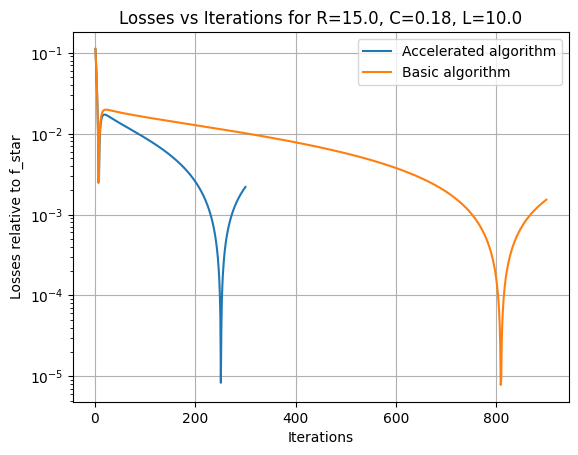

In [171]:
# -- Accelerated optimization problem
e12 = e13 = e14 = e15 = 0.0
i12 = i13 = i14 = i15 = 0.0


e_C = 0.0
i_C = 0.0

losses2 = []
K = 300
H = 0.005
for k in range(K):
    h = H/np.sqrt(1 + k)
    # 1) form your “inputs” into each prox
    z1 = (R*i12 + e12 + R*i13 + e13 + R*i14 + e14 + R*i15 + e15 + R*i_C + e_C)/5
    z2 = R*i12 + e12
    z3 = R*i13 + e13
    z4 = R*i14 + e14
    z5 = R*i15 + e15

    # 2) call the two proximal routines
    x1 = prox_star_node1(z1, R/5, A, c[0], a[0])
    x2 = prox_star_leaf(z2, R, c[1], a[1])
    x3 = prox_star_leaf(z3, R, c[2], a[2])
    x4 = prox_star_leaf(z4, R, c[3], a[3])
    x5 = prox_star_leaf(z5, R, c[4], a[4])

    # 3) turn those into subgradient‐currents
    y1 = (5/R)*(z1 - x1)
    y2 = (1/R)*(z2 - x2)
    y3 = (1/R)*(z3 - x3)
    y4 = (1/R)*(z4 - x4)
    y5 = (1/R)*(z5 - x5)

    # 4) update your interconnect “voltages” (mid-edge nodes)
    e12_new = 0.5*(x1 + x2)
    e13_new = 0.5*(x1 + x3)
    e14_new = 0.5*(x1 + x4)
    e15_new = 0.5*(x1 + x5)

    # 5) update your “inductor currents”
    i12_new = i12 + (h/L)*(e12_new - x1)
    i13_new = i13 + (h/L)*(e13_new - x1)
    i14_new = i14 + (h/L)*(e14_new - x1)
    i15_new = i15 + (h/L)*(e15_new - x1)

    # 5b) update capacitor state
    e_C_new = e_C - (h/C) * (
        i_C
    + i12 + i13 + i14 + i15
    + (e_C - x1) / R
    )
    i_C_new = i_C + (h/L)*(e_C - x1)

    # 5c) commit both sets of states
    e_C, i_C = e_C_new, i_C_new

    # 6) commit the new states
    e12, e13, e14, e15 = e12_new, e13_new, e14_new, e15_new
    i12, i13, i14, i15 = i12_new, i13_new, i14_new, i15_new

    # 7) (optionally) measure the current objective‐gap
    xk = x1
    fk = A*(xk - c[0])**2 + np.sum(a*np.abs(xk - c))
    losses2.append(abs(fk - f_star)/f_star)
    print(f"iter {k+1}: {losses2[-1]}")

print(f"optimal value: {xk}, optimal risk: {fk}")



X_epoch2 = np.arange(1, K+1)
plt.semilogy(X_epoch2, losses2, label="Accelerated algorithm")
plt.semilogy(X_epoch1, losses1, label="Basic algorithm")
plt.xlabel("Iterations")
plt.ylabel(f"Losses relative to f_star")
plt.title(f"Losses vs Iterations for R={R}, C={C:.2f}, L={L}")
plt.legend()
plt.grid()
plt.show()
# -- plot the losses